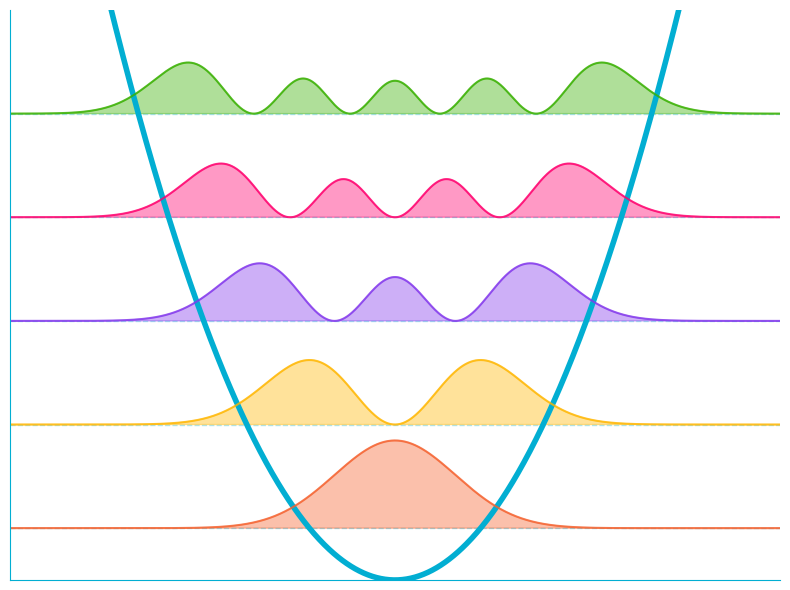

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite
import math

# Color for the potential well
COLOR_CYAN = '#02AED2'

# Distinct color palette for the 5 probability densities
WAVE_COLORS = ['#F5622F', '#FFB703', '#8338EC', '#FF006E', '#38B000']

# Spatial grid (dimensionless units)
x = np.linspace(-5, 5, 1000)

# Parabolic potential well V(x) = 0.5 * x^2
V = 0.5 * x**2

# Initialize the minimalist plot
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

# Plot the potential curve with a thicker line
ax.plot(x, V, color=COLOR_CYAN, lw=4)

# Calculate and plot the first 5 eigenstates
num_states = 5
for n in range(num_states):
    # Energy levels E_n = n + 1/2
    E_n = n + 0.5
    
    # Normalized wavefunction
    N_n = 1.0 / np.sqrt(2**n * math.factorial(n) * np.sqrt(np.pi))
    psi_n = N_n * np.exp(-0.5 * x**2) * eval_hermite(n, x)
    
    # Probability density |psi|^2
    prob_density = np.abs(psi_n)**2
    
    # Scale for visual clarity and offset by the energy level
    y_fill = E_n + prob_density * 1.5
    
    # Energy level reference line
    ax.axhline(E_n, color=COLOR_CYAN, lw=1, linestyle='--', alpha=0.3)
    
    # Solid fill (more transparent) and outline for each state
    color = WAVE_COLORS[n % len(WAVE_COLORS)]
    ax.fill_between(x, E_n, y_fill, color=color, alpha=0.4)
    ax.plot(x, y_fill, color=color, lw=1.5, alpha=0.8)

# Minimalist formatting: remove unnecessary spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLOR_CYAN)
ax.spines['bottom'].set_color(COLOR_CYAN)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, num_states + 0.5)

plt.tight_layout()
plt.show()

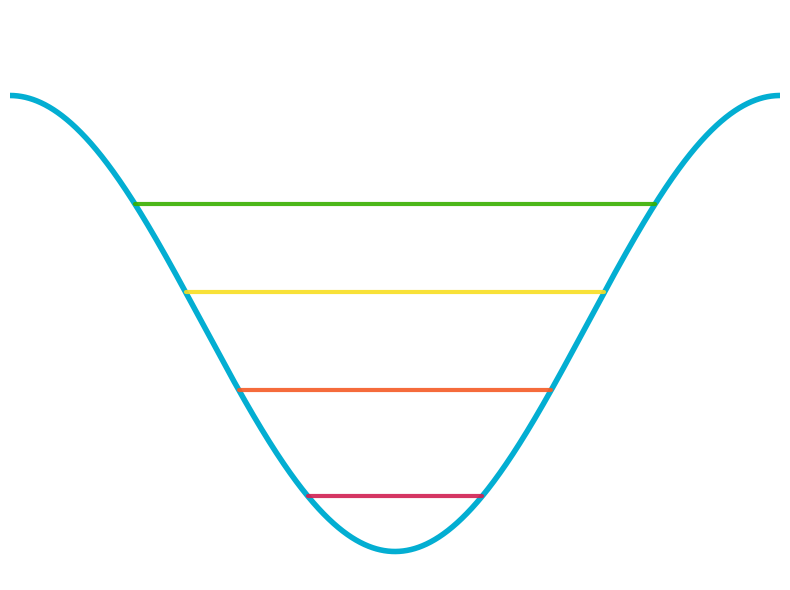

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Color for the potential well
COLOR_CYAN = '#03AED2'

# Distinct color palette for the energy levels
WAVE_COLORS = ['#D12052', '#F45B26', '#F8DE22', '#38B000']

# ------------------------------------------------------------------
# Cosine ("washboard") potential, as in a Josephson junction:
#   V(x) = -E_J * cos(x)
# The bound-state energies are found by diagonalizing the
# Hamiltonian on a finite-difference grid (equivalent to solving
# the Mathieu equation).
# ------------------------------------------------------------------

E_J = 4.0          # potential depth / Josephson energy (sets how many bound states exist)
hbar = 1.0
m = 1.0

# Spatial grid: a single well, with hard walls at the potential's maxima
# (x = -pi to +pi). This avoids the near-degenerate doublets that appear
# when the grid spans multiple wells and states can tunnel between them.
x = np.linspace(-np.pi, np.pi, 2000)
dx = x[1] - x[0]

V = -E_J * np.cos(x)

# Build the Hamiltonian: kinetic (finite-difference 2nd derivative) + potential
# Dirichlet boundary conditions (psi = 0 at the walls) are implicit since we
# only diagonalize the interior grid points.
main_diag = 1.0 / dx**2 + V
off_diag = -0.5 / dx**2 * np.ones(len(x) - 1)

H = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)

# Diagonalize (H is real symmetric -> use eigh)
eigvals, eigvecs = np.linalg.eigh(H)

# Keep only the bound states, i.e. energies below the top of the barrier (V_max = +E_J)
num_states = 4
E_levels = eigvals[:num_states]

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

# Plot the potential curve with a thicker line
ax.plot(x, V, color=COLOR_CYAN, lw=4)

# For each bound state, draw a horizontal segment spanning the
# classically allowed region (between the turning points), the same
# way the energy-level dashed lines work in the harmonic-oscillator
# plot -- just without the wavefunction fill.
for n, E_n in enumerate(E_levels):
    color = WAVE_COLORS[n % len(WAVE_COLORS)]

    # Exact classical turning points: solve -E_J*cos(x) = E_n  ->  x = +/- arccos(-E_n/E_J)
    # (valid for the central well, |E_n| <= E_J; falls back to the maxima otherwise)
    ratio = np.clip(-E_n / E_J, -1.0, 1.0)
    x_right = np.arccos(ratio)
    x_left = -x_right

    # solid, colored segment that ends exactly where it meets the cosine potential
    ax.plot([x_left, x_right], [E_n, E_n], color=color, lw=3, alpha=0.9,
             solid_capstyle='round')

# Minimalist formatting: remove unnecessary spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-E_J - 0.5, E_J + 1.5)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/cosine_potential.png', dpi=150, facecolor='white')
plt.show()